# Regressão linear e descida do gradiente

**Capítulo 2 — Fundamentos Matemáticos do Aprendizado de Máquina**  
Rafael Kunst · Tempo estimado: 35–50 minutos

Neste notebook, uma regressão linear conecta matrizes, derivadas e otimização.
Ao final, você deverá conseguir construir a matriz de projeto, derivar e verificar
o gradiente, comparar um método iterativo com mínimos quadrados e interpretar
o efeito da taxa de aprendizado e da escala dos atributos.

**Pré-requisitos:** operações matriciais, derivadas parciais e Python básico.
Leia no Capítulo 2 as partes sobre mínimos quadrados, gradientes e otimização.

## 1. Ambiente e dados

Execute todas as células em ordem, com kernel reiniciado. São necessários NumPy
e Matplotlib; as instruções completas estão no README do repositório.
Não há downloads, chamadas de API nem necessidade de GPU.

Os dados são **inteiramente sintéticos**: horas de operação e uma medida fictícia
de desgaste. Eles ilustram uma relação linear com ruído; não sustentam inferências
sobre equipamentos reais. A semente fixa permite repetir o experimento.

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

SEMENTE = 42
rng = np.random.default_rng(SEMENTE)
plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True,
                     "grid.alpha": 0.2, "font.size": 11})
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__, "| Matplotlib:", matplotlib.__version__)

Python: 3.13.15
NumPy: 2.1.3 | Matplotlib: 3.10.0


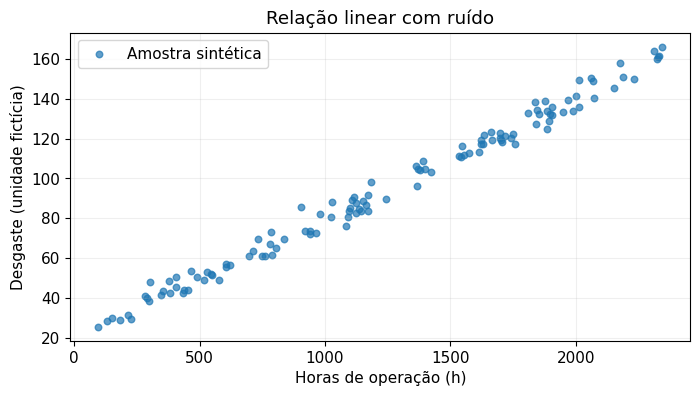

In [2]:
n = 120
horas = rng.uniform(80, 2400, size=n)
intercepto_gerador, inclinacao_gerador = 20.0, 0.06
ruido = rng.normal(loc=0.0, scale=4.0, size=n)
desgaste = intercepto_gerador + inclinacao_gerador * horas + ruido

fig, ax = plt.subplots()
ax.scatter(horas, desgaste, s=22, alpha=0.7, label="Amostra sintética")
ax.set(xlabel="Horas de operação (h)", ylabel="Desgaste (unidade fictícia)",
       title="Relação linear com ruído")
ax.legend()
plt.show()

## 2. Matriz de projeto e escala

Escrevemos $\widehat{\mathbf y}=\mathbf X\mathbf w$, com uma coluna de uns para
o intercepto. Aqui, $\mathbf X\in\mathbb R^{n\times2}$ e $\mathbf w=(w_0,w_1)^T$.
Padronizamos as horas por $z=(x-\mu)/s$, usando o desvio-padrão populacional da
amostra (`ddof=0`). A coluna do intercepto permanece igual a 1.

Este é um **experimento de otimização em uma amostra fixa**: todos os dados são
usados para ajustar e comparar os algoritmos. A perda reportada é de ajuste,
não uma estimativa de generalização. Em uma avaliação preditiva, a separação dos
dados deve anteceder o cálculo de média e desvio, que usam somente o treino.

In [3]:
media = horas.mean()
escala = horas.std(ddof=0)
z = (horas - media) / escala
X = np.column_stack([np.ones(n), z])
X_bruta = np.column_stack([np.ones(n), horas])
y = desgaste
print("X:", X.shape, "y:", y.shape)
print("Média de z:", z.mean(), "Desvio de z:", z.std(ddof=0))

X: (120, 2) y: (120,)
Média de z: 1.7763568394002506e-16 Desvio de z: 1.0


## 3. Função de custo e derivação

O capítulo apresenta a soma dos erros quadráticos. Para facilitar a implementação,
usamos uma versão reescalada:

$$J(\mathbf w)=\frac{1}{2n}\|\mathbf X\mathbf w-\mathbf y\|_2^2.$$

Multiplicar a função por uma constante positiva não altera seu minimizador,
mas altera o gradiente e a taxa de aprendizado apropriada.
Definindo $\mathbf r=\mathbf X\mathbf w-\mathbf y$ e expandindo o produto:

$$J=\frac{1}{2n}(\mathbf w^T\mathbf X^T\mathbf X\mathbf w
-2\mathbf w^T\mathbf X^T\mathbf y+\mathbf y^T\mathbf y).$$

Como $\mathbf X^T\mathbf X$ é simétrica, a derivação produz

$$\nabla J(\mathbf w)=\frac{1}{n}\mathbf X^T(\mathbf X\mathbf w-\mathbf y).$$

O custo é escalar; o gradiente tem dois elementos, um por parâmetro.
O erro quadrático médio, MSE, equivale a $2J$ nesta convenção.

In [4]:
def custo(X, y, w):
    residuos = X @ w - y
    return float(residuos @ residuos / (2 * len(y)))


def gradiente(X, y, w):
    return X.T @ (X @ w - y) / len(y)


w_inicial = np.zeros(X.shape[1])
print("Custo inicial:", custo(X, y, w_inicial))
print("Gradiente inicial:", gradiente(X, y, w_inicial))

Custo inicial: 5162.871001583191
Gradiente inicial: [-94.18479738 -37.93044194]


## 4. Verificar a derivada

Uma diferença finita central aproxima cada componente do gradiente:

$$\frac{\partial J}{\partial w_j}\approx
\frac{J(\mathbf w+h\mathbf e_j)-J(\mathbf w-h\mathbf e_j)}{2h}.$$

Essa aproximação serve para conferir a implementação, não para substituir a
derivada analítica no treinamento. Passos muito grandes aumentam erro de
aproximação; passos muito pequenos podem causar cancelamento numérico.

In [5]:
w_verificacao = np.array([2.0, -1.0])
h = 1e-4
grad_numerico = np.empty_like(w_verificacao)
for j in range(len(w_verificacao)):
    direcao = np.zeros_like(w_verificacao)
    direcao[j] = h
    grad_numerico[j] = (
        custo(X, y, w_verificacao + direcao)
        - custo(X, y, w_verificacao - direcao)
    ) / (2 * h)

grad_analitico = gradiente(X, y, w_verificacao)
np.testing.assert_allclose(grad_analitico, grad_numerico, rtol=1e-6, atol=1e-6)
print("Analítico:", grad_analitico)
print("Numérico:", grad_numerico)
print("Verificação do gradiente aprovada.")

Analítico: [-92.18479738 -38.93044194]
Numérico: [-92.18479739 -38.93044195]
Verificação do gradiente aprovada.


## 5. Solução de referência e curvatura

Igualar o gradiente a zero leva às equações normais
$\mathbf X^T\mathbf X\mathbf w=\mathbf X^T\mathbf y$.
Usamos `np.linalg.lstsq`, evitando formar uma inversa explicitamente.
Com posto completo, o minimizador é único.

A Hessiana é $\mathbf H=\mathbf X^T\mathbf X/n$.
Para esta função quadrática estritamente convexa, o gradiente com passo fixo
converge quando $0<\eta<2/L$, sendo $L$ o maior autovalor de $\mathbf H$.
O limite depende da função e de sua escala; não é uma regra universal para redes neurais.

In [6]:
w_referencia, _, posto, _ = np.linalg.lstsq(X, y, rcond=None)
assert posto == X.shape[1]
H = X.T @ X / n
autovalores = np.linalg.eigvalsh(H)
L = autovalores[-1]
print("Coeficientes na escala padronizada:", w_referencia)
print("Custo mínimo na amostra:", custo(X, y, w_referencia))
print("Autovalores da Hessiana:", autovalores)
print("Intervalo de convergência: 0 < eta <", 2 / L)

Coeficientes na escala padronizada: [94.18479738 37.93044194]
Custo mínimo na amostra: 8.123759366356685
Autovalores da Hessiana: [1. 1.]
Intervalo de convergência: 0 < eta < 1.9999999999999996


## 6. Descida do gradiente em lote

A atualização é $\mathbf w_{t+1}=\mathbf w_t-\eta\nabla J(\mathbf w_t)$.
Cada passo utiliza toda a amostra. Registramos a trajetória para examinar o
processo e paramos quando a norma do gradiente fica abaixo da tolerância ou
quando atingimos o limite de iterações. A tolerância é uma decisão numérica.

In [7]:
def descida_gradiente(X, y, eta, max_iter=500, tolerancia=1e-9):
    w = np.zeros(X.shape[1])
    trajetoria = [w.copy()]
    custos = [custo(X, y, w)]
    for _ in range(max_iter):
        g = gradiente(X, y, w)
        if np.linalg.norm(g) < tolerancia:
            break
        w = w - eta * g
        novo_custo = custo(X, y, w)
        if not np.isfinite(novo_custo):
            raise FloatingPointError("Custo não finito: reveja a taxa de aprendizado.")
        trajetoria.append(w.copy())
        custos.append(novo_custo)
    return w, np.asarray(custos), np.asarray(trajetoria)


w_gd, custos, trajetoria = descida_gradiente(X, y, eta=0.15 / L)
np.testing.assert_allclose(w_gd, w_referencia, rtol=1e-7, atol=1e-7)
assert np.all(np.diff(custos) <= 1e-9)
print("Passos:", len(custos) - 1)
print("Norma final do gradiente:", np.linalg.norm(gradiente(X, y, w_gd)))
print("Distância à referência:", np.linalg.norm(w_gd - w_referencia))

Passos: 156
Norma final do gradiente: 9.907653029488088e-10
Distância à referência: 9.907922707528872e-10


## 7. Interpretar os parâmetros e o ajuste

Os coeficientes acima atuam sobre $z$, não sobre horas diretamente.
Voltando à unidade original:

$$b_1=w_1/s,\qquad b_0=w_0-w_1\mu/s.$$

O coeficiente $b_1$ indica variação predita do desgaste por hora neste modelo.
Os parâmetros estimados não precisam coincidir exatamente com os do gerador:
há ruído e amostra finita. A relação construída é didática, não causal.

Gerador: intercepto=20.000, inclinação=0.06000
Ajuste:  intercepto=19.994, inclinação=0.05998
MSE de ajuste: 16.248


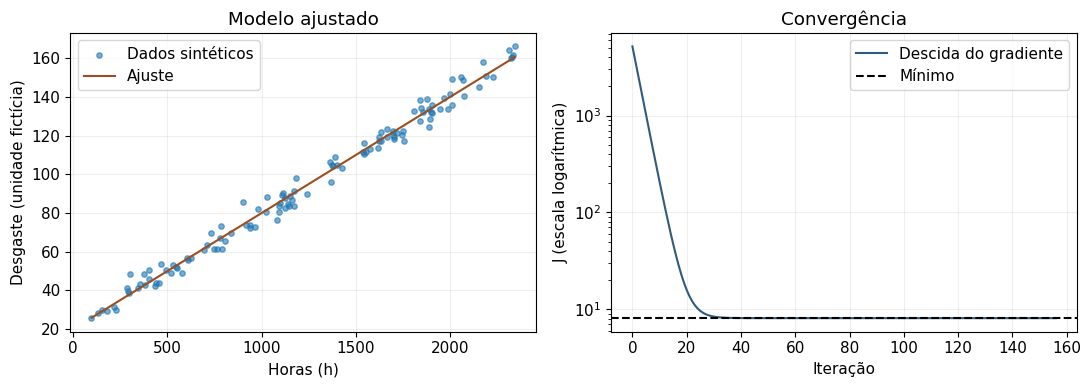

In [8]:
b1 = w_gd[1] / escala
b0 = w_gd[0] - w_gd[1] * media / escala
print(f"Gerador: intercepto={intercepto_gerador:.3f}, inclinação={inclinacao_gerador:.5f}")
print(f"Ajuste:  intercepto={b0:.3f}, inclinação={b1:.5f}")
print(f"MSE de ajuste: {2 * custo(X, y, w_gd):.3f}")

ordem = np.argsort(horas)
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].scatter(horas, y, s=15, alpha=0.6, label="Dados sintéticos")
eixos[0].plot(horas[ordem], (X @ w_gd)[ordem], color="#9a4e21", label="Ajuste")
eixos[0].set(xlabel="Horas (h)", ylabel="Desgaste (unidade fictícia)", title="Modelo ajustado")
eixos[0].legend()
eixos[1].semilogy(custos, color="#315b7d", label="Descida do gradiente")
eixos[1].axhline(custo(X, y, w_referencia), color="black", linestyle="--", label="Mínimo")
eixos[1].set(xlabel="Iteração", ylabel="J (escala logarítmica)", title="Convergência")
eixos[1].legend()
fig.tight_layout()
plt.show()

## 8. Taxa de aprendizado: lento, rápido e instável

Comparamos três passos relativos a $L$. Um passo pequeno progride lentamente;
um passo intermediário converge mais rápido neste exemplo; um passo acima de
$2/L$ se afasta do mínimo. Com as condições iniciais utilizadas, essa divergência
aparece na curva. Não se deve escolher a taxa com base em um conjunto de teste.

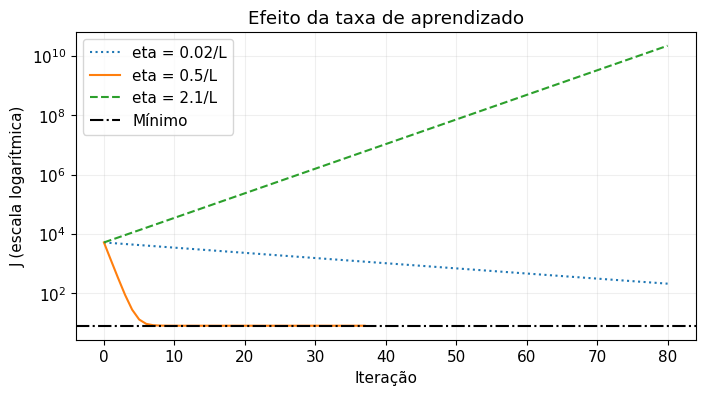

In [9]:
fig, ax = plt.subplots()
for fator, estilo in [(0.02, ":"), (0.5, "-"), (2.1, "--")]:
    _, curva, _ = descida_gradiente(X, y, eta=fator / L, max_iter=80)
    ax.semilogy(curva, linestyle=estilo, label=f"eta = {fator}/L")
ax.axhline(custo(X, y, w_referencia), color="black", linestyle="-.", label="Mínimo")
ax.set(xlabel="Iteração", ylabel="J (escala logarítmica)", title="Efeito da taxa de aprendizado")
ax.legend()
plt.show()

## 9. Escala dos atributos e condicionamento

Compare a razão entre o maior e o menor autovalor da Hessiana antes e depois da
padronização. Uma razão elevada indica curvaturas muito diferentes: um passo
estável na direção mais curva pode ser lento em outra direção.

Neste exemplo especial de um único atributo centrado e com variância unitária,
a Hessiana padronizada é aproximadamente a identidade. Em problemas com vários
atributos correlacionados, padronizar não elimina necessariamente o mau condicionamento.

In [10]:
H_bruta = X_bruta.T @ X_bruta / n
eig_brutos = np.linalg.eigvalsh(H_bruta)
print("Condicionamento da Hessiana bruta:", eig_brutos[-1] / eig_brutos[0])
print("Condicionamento da Hessiana padronizada:", autovalores[-1] / autovalores[0])

w_bruto, curva_bruta, _ = descida_gradiente(
    X_bruta, y, eta=1 / eig_brutos[-1], max_iter=500
)
print("Custo bruto após 500 passos:", custo(X_bruta, y, w_bruto))
print("Custo padronizado ao convergir:", custo(X, y, w_gd))
print("O passo foi ajustado à curvatura de cada representação.")

Condicionamento da Hessiana bruta: 9314653.266310744
Condicionamento da Hessiana padronizada: 1.0000000000000002
Custo bruto após 500 passos: 49.53786994473489
Custo padronizado ao convergir: 8.123759366356685
O passo foi ajustado à curvatura de cada representação.


## 10. Atividades complementares

1. Substitua a perda por MSE, sem o fator 1/2. Derive o novo gradiente e explique
   como adaptar a taxa para preservar a mesma sequência de parâmetros.
2. Aumente o ruído de 4 para 12. Compare o MSE mínimo e a diferença entre parâmetros
   ajustados e os do gerador. Não confunda ruído irredutível com falha do otimizador.
3. Acrescente um segundo atributo fortemente correlacionado com as horas. Examine
   posto, autovalores e condicionamento antes e depois de padronizar.
4. Transforme o experimento em avaliação preditiva: separe treino e teste antes de
   padronizar, ajuste tudo no treino e reporte MSE no teste. Se comparar taxas ou
   modelos, use validação dentro do treino e preserve o teste para o final.

Essas atividades são adicionais e não substituem a lista de exercícios do capítulo.

## Conclusão

A implementação reproduz o gradiente derivado e converge para a solução numérica
de mínimos quadrados. O exemplo mostra o efeito de escala e taxa de aprendizado,
mas não estabelece desempenho em dados novos. Regressão linear é convexa; a mesma
garantia de convergência não se transfere automaticamente a modelos não convexos.

## Referências e licenças

- Capítulo 2 do livro: mínimos quadrados, gradientes e otimização.
- [NumPy: `linalg.lstsq`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html).
- [NumPy: `linalg.eigvalsh`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigvalsh.html).
- [Repositório e condições de uso](https://github.com/rkunst/LivroML).

Copyright © 2026 Rafael Kunst. Células de código: MIT. Texto didático e figuras
originais: CC BY 4.0. Consulte `LICENSE` e `LICENSE-CONTENT.md` no repositório.